# Compare ABC kernel, GMM, and SBI on the same Local Group pair catalogue

This notebook is self-contained: it loads simulation data, rebuilds the pair catalogue, filters to blue-blue and red-red pairs only, and compares three inference methods.

The target is taken directly from `pairs.log_tot_virial_mass`.

The active feature set, target metadata, and analogue-selection settings come from `config/config.json` via `config.loader.load_config()`.


## 1) Imports and helper modules

This notebook builds the analogue sample in the same way as `generate_analogues.ipynb`, through the `analogues.AnalogueSample` workflow.

The setup below resolves the repo root and TNG outputs path automatically, loads the shared analysis config from `config/config.json`, and then creates:

- `analogue_sample`
- `sub`
- `sample`
- `pair_set`
- `pipeline`
- `halos`

so the comparison cells can run from a fresh kernel without a hardcoded colleague-specific path.


In [25]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = next((path for path in [cwd, *cwd.parents] if (path / "analogues").is_dir()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find the repo root containing the `analogues` package.")

candidate_paths = [
    repo_root,
    repo_root / "scripts",
    repo_root / "illustris_python",
    Path("/mnt/data"),
]
for pth in candidate_paths:
    if pth.exists() and str(pth) not in sys.path:
        sys.path.insert(0, str(pth))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import illustris_python as il

from analogues import AnalogueSample, FilterConfig, SelectionConfig
from config.loader import load_config
from lg_abc import run_abc_catalog, summarize_posterior
from lg_gmm_kde import (
    prepare_density_problem,
    fit_joint_gmm,
    condition_gmm,
    weighted_gaussian_kde_1d,
)
from lg_sbi import (
    fit_catalog_npe,
    infer_with_npe,
    plot_sbc_rank_hist,
    plot_expected_coverage,
)

print("Repo root:", repo_root)
print("Imports loaded successfully.")


Repo root: /home/tp/Documents/uni/dsp
Imports loaded successfully.


## 2) Load the shared analysis configuration

The main scientific choices come from `config/config.json`:

- analogue-selection cuts
- pair-filter cuts
- active observed features
- active target metadata

In this notebook, the target values are always sourced from `pairs.log_tot_virial_mass`.


In [26]:
def resolve_base_path(repo_root: Path) -> str:
    raw_candidates = [
        os.environ.get("TNG_BASE_PATH"),
        os.environ.get("ILLUSTRIS_BASE_PATH"),
        str(repo_root / "tng300" / "outputs"),
    ]

    for raw in raw_candidates:
        if not raw:
            continue
        base = Path(raw).expanduser()
        for candidate in (base, base / "tng300" / "outputs"):
            if (candidate / "groups_099").exists():
                return str(candidate.resolve())

    raise FileNotFoundError(
        "Could not find a valid TNG outputs directory. Set TNG_BASE_PATH or ILLUSTRIS_BASE_PATH "
        "to the outputs directory, or to a root that contains tng300/outputs."
    )


config_loader = load_config()
analysis_config = config_loader.get_config()

FEATURE_INFO = analysis_config.features
ACTIVE_FEATURES = list(FEATURE_INFO.keys())
if not ACTIVE_FEATURES:
    raise ValueError("config/config.json must have at least one active feature.")

TARGET_KEY = "total_virial_mass"
TARGET = "log_tot_virial_mass"
TARGET_LOG10 = False
TARGET_LABEL = "Log Total virial mass"
LOG10_FEATURES = {
    name for name, meta in FEATURE_INFO.items()
    if bool(meta.get("log10", False))
}

ABC_HELPER_ACCEPT_FRAC = 0.05
ABC_KERNEL_BANDWIDTH = 1.0

GMM_COMPONENTS = "bic"
GMM_RANDOM_STATE = 42

'''
{'density_model': 'maf',
 'hidden_features': 128,
 'num_transforms': 4,
 'training_batch_size': 256,
 'learning_rate': 0.0003039606114252441,
 'validation_fraction': 0.10128603282380315,
 'stop_after_epochs': 30}
'''
SBI_CONFIG = {
    "density_model": "maf",
    "hidden_features": 128,
    "num_transforms": 4,
    "training_batch_size": 256,
    "learning_rate": 3e-4,
    "validation_fraction": 0.1,
    "calibration_fraction": 0.2,
    "stop_after_epochs": 30,
    "max_num_epochs": 300,
    "random_state": 42,
    "show_train_summary": False,
}



DIAG_TEST_FRACTION = 0.25
DIAG_RANDOM_STATE = 42


def build_x_obs_and_sigma(feature_info, active_features):
    x_obs = np.array([feature_info[name]["obs"] for name in active_features], dtype=float)
    sigma = np.array([feature_info[name]["sigma"] for name in active_features], dtype=float)
    return x_obs, sigma


x_obs, sigma = build_x_obs_and_sigma(FEATURE_INFO, ACTIVE_FEATURES)

BASE_PATH = resolve_base_path(repo_root)
SNAP = 99

ANALOGUE_SELECTION_CONFIG = SelectionConfig(**analysis_config.selection)
ANALOGUE_FILTER_CONFIG = FilterConfig(**analysis_config.filter)

feature_df = pd.DataFrame([
    {
        "feature": name,
        "observed_value": FEATURE_INFO[name]["obs"],
        "sigma": FEATURE_INFO[name]["sigma"],
        "label": FEATURE_INFO[name].get("label", name),
        "description": FEATURE_INFO[name].get("description", ""),
    }
    for name in ACTIVE_FEATURES
])

print("Active feature configuration:")
display(feature_df)
print("Active target from config metadata:")
display(config_loader.show_active_target())
print("Selection config:")
display(pd.DataFrame([analysis_config.selection]))
print("Filter config:")
display(pd.DataFrame([analysis_config.filter]))

print("Target enforced by notebook path:", TARGET, "| log10:", TARGET_LOG10)
print("x_obs =", x_obs)
print("sigma =", sigma)
print("BASE_PATH =", BASE_PATH)
print("SNAP =", SNAP)


Active feature configuration:


,feature,observed_value,sigma,label,description
0,r_kpc,7.650000e+02,1.100000e+01,Pair separation $r$ [kpc],Current MW-M31 separation proxy.
1,v_r,-1.093000e+02,4.400000e+00,Radial velocity $v_r$ [km/s],Relative radial velocity of the pair.
2,v_t,5.700000e+01,3.500000e+01,Tangential velocity $v_t$ [km/s],Relative tangential velocity of the pair.
3,mstar_big,5.000000e+10,1.000000e+10,Larger stellar mass,Stellar mass of the more massive member.
4,mstar_small,4.000000e+10,1.000000e+10,Smaller stellar mass,Stellar mass of the less massive member.


Active target from config metadata:


,column,log10,active,label,description
total_virial_mass,log_tot_virial_mass,False,True,Log Total virial mass,"Total virial mass of the pair,"


Selection config:


,m_stellar_min,m_stellar_max,r_min,r_max,blue_threshold_gr
0,2.000000e+10,5.000000e+11,500.0,1000.0,0.68


Filter config:


,v_tot_min,v_tot_max,vt_min,vt_max,vr_min,vr_max,density_radius,intruder_factor,third_massive_factor
0,0,600,0,300,-400,0,2000,0.5,1.5


Target enforced by notebook path: log_tot_virial_mass | log10: False
x_obs = [ 7.650e+02 -1.093e+02  5.700e+01  5.000e+10  4.000e+10]
sigma = [1.1e+01 4.4e+00 3.5e+01 1.0e+10 1.0e+10]
BASE_PATH = /home/tp/Documents/uni/dsp/tng300/outputs
SNAP = 99


In [27]:
# Build the analogue sample using the same workflow as generate_analogues.ipynb.
base_path = BASE_PATH
snap = SNAP

analogue_sample = AnalogueSample(
    base_path=base_path,
    selection_config=ANALOGUE_SELECTION_CONFIG,
    filter_config=ANALOGUE_FILTER_CONFIG,
    verbose=True,
    snap=snap,
)

sub = analogue_sample._sub
sample = analogue_sample._sample
pair_set = analogue_sample._pair_set
pipeline = analogue_sample._pipeline

display(pd.DataFrame(pipeline.get_cutflow()))

print("Loaded subhalos:", sub["count"])
print("Selected objects:", sample.keep_idx.size)
print("Pairs before filtering:", pair_set.i.size)
print("Pairs after filtering:", pipeline.pairs.i.size)



[DIAGNOSTIC] Simulation Header Constants
╒════════════╤═══════════╤═══════════════╕
│ Parameter  │ Value     │ Units         │
├────────────┼───────────┼───────────────┤
│ Hubble (h) │ 0.6774    │ dimensionless │
├────────────┼───────────┼───────────────┤
│ Box Side   │ 302627.69 │ kpc           │
╘════════════╧═══════════╧═══════════════╛

[DIAGNOSTIC] Sample Selection
╒═════════════════════════════════════════╤══════════╤═════════════════╕
│ Selection Step                          │    Count │ Yield           │
╞═════════════════════════════════════════╪══════════╪═════════════════╡
│ Total Subhalos in Catalog               │ 14485709 │ 100.0%          │
├─────────────────────────────────────────┼──────────┼─────────────────┤
│ Passed Quality Flags (SubhaloFlag==1)   │  1902558 │ 13.1%           │
├─────────────────────────────────────────┼──────────┼─────────────────┤
│ Inside Stellar Mass Window              │    60562 │ 3.2% of good    │
├─────────────────────────────────────────

,label,before,after,frac_kept
0,initial,2655,2655,1.000000
1,No third subhalo more massive than factor x=1....,2655,2601,0.979661
2,No subhalos more massive than factor x=0.5 wit...,2601,2600,0.999616
3,"vt in [0, 300], vr in [-400, 0], v_tot in [0, ...",2600,1761,0.677308


Loaded subhalos: 14485709
Selected objects: 45392
Pairs before filtering: 2655
Pairs after filtering: 1761


## 3) Build the final pair catalogue and apply the color policy

This notebook keeps only blue-blue and red-red pairs.

- `blue-blue` and `red-red` are retained
- `mixed blue-red` pairs are dropped from all methods

The target is taken directly from `pairs.log_tot_virial_mass`.


In [28]:
# Build the final pair catalogue from the analogue sample created above.
pairs = analogue_sample.pairs
pair_i = pairs.i
pair_j = pairs.j

mstar_i = sample.m_stellar[pair_i].astype(np.float64, copy=False)
mstar_j = sample.m_stellar[pair_j].astype(np.float64, copy=False)
mdm_i = sample.m_dark_matter[pair_i].astype(np.float64, copy=False)
mdm_j = sample.m_dark_matter[pair_j].astype(np.float64, copy=False)
k_band_i = sample.k_band[pair_i].astype(np.float64, copy=False)
k_band_j = sample.k_band[pair_j].astype(np.float64, copy=False)

is_blue_blue = np.asarray(pairs.is_blue_blue, dtype=bool)
is_red_red = np.asarray(pairs.is_red_red, dtype=bool)
is_blue_red = np.asarray(pairs.is_blue_red, dtype=bool)
keep_color_mask = is_blue_blue | is_red_red

color_summary = pd.DataFrame([{
    "total_pairs": int(pairs.i.size),
    "blue_blue": int(is_blue_blue.sum()),
    "red_red": int(is_red_red.sum()),
    "mixed_blue_red_removed": int(is_blue_red.sum()),
    "retained_after_color_filter": int(keep_color_mask.sum()),
}])
print("Color-policy summary:")
display(color_summary)

catalog = {
    "r_kpc": pairs.separation.astype(np.float64, copy=False),
    "v_r": pairs.vr.astype(np.float64, copy=False),
    "v_t": pairs.vt.astype(np.float64, copy=False),
    "same_host": pairs.have_same_host.astype(np.float64, copy=False),
    "mstar_i": mstar_i,
    "mstar_j": mstar_j,
    "k_band_small": k_band_i,
    "k_band_large": k_band_j,
    "mstar_big": np.maximum(mstar_i, mstar_j),
    "mstar_small": np.minimum(mstar_i, mstar_j),
    "mdm_i": mdm_i,
    "mdm_j": mdm_j,
    "mdm_sum": mdm_i + mdm_j,
    "mdm_big": np.maximum(mdm_i, mdm_j),
    "mdm_small": np.minimum(mdm_i, mdm_j),
    "dm_mass_ratio": np.maximum(mdm_i, mdm_j) / np.clip(np.minimum(mdm_i, mdm_j), 1e-30, None),
    "mstar_sum": mstar_i + mstar_j,
    "log_tot_virial_mass": pairs.log_tot_virial_mass.astype(np.float64, copy=False),
    "pair_is_red_red": is_red_red.astype(np.float64),
}

# Apply blue-blue/red-red only mask to every catalog column.
for key in list(catalog.keys()):
    catalog[key] = np.asarray(catalog[key])[keep_color_mask]

problem = prepare_density_problem(
    catalog=catalog,
    features=ACTIVE_FEATURES,
    target=TARGET,
    log10_features=LOG10_FEATURES,
    target_log10=TARGET_LOG10,
)

X = problem["X"]
theta = problem["theta"]
feature_names = problem["feature_names"]
target_name = TARGET_LABEL

# Helpful arrays for diagnostics.
redred_retained = catalog["pair_is_red_red"].astype(bool)
blublu_retained = ~redred_retained

print("Pairs after color-policy + finite filtering:", X.shape[0])
print("Number of active features:", X.shape[1])
print("Dropped non-finite rows:", problem["dropped_rows"])
print("Target column:", TARGET)
print("Target label:", target_name)
print("Retained blue-blue:", int(blublu_retained.sum()))
print("Retained red-red:", int(redred_retained.sum()))

prior_summary = summarize_posterior(theta)
display(pd.DataFrame([prior_summary], index=["all retained pairs after S + color filter"]))


Color-policy summary:


,total_pairs,blue_blue,red_red,mixed_blue_red_removed,retained_after_color_filter
0,1761,198,827,736,1025


Pairs after color-policy + finite filtering: 1025
Number of active features: 5
Dropped non-finite rows: 0
Target column: log_tot_virial_mass
Target label: Log Total virial mass
Retained blue-blue: 198
Retained red-red: 827


,mean,median,q16,q84
all retained pairs after S + color filter,12.896249,12.829658,12.534827,13.307546


## 4) Sanity plots before inference

These plots answer two basic questions:

1. Is the observed system inside the support of the retained analogue catalogue?
2. Which active features already look common or unusual before conditioning?


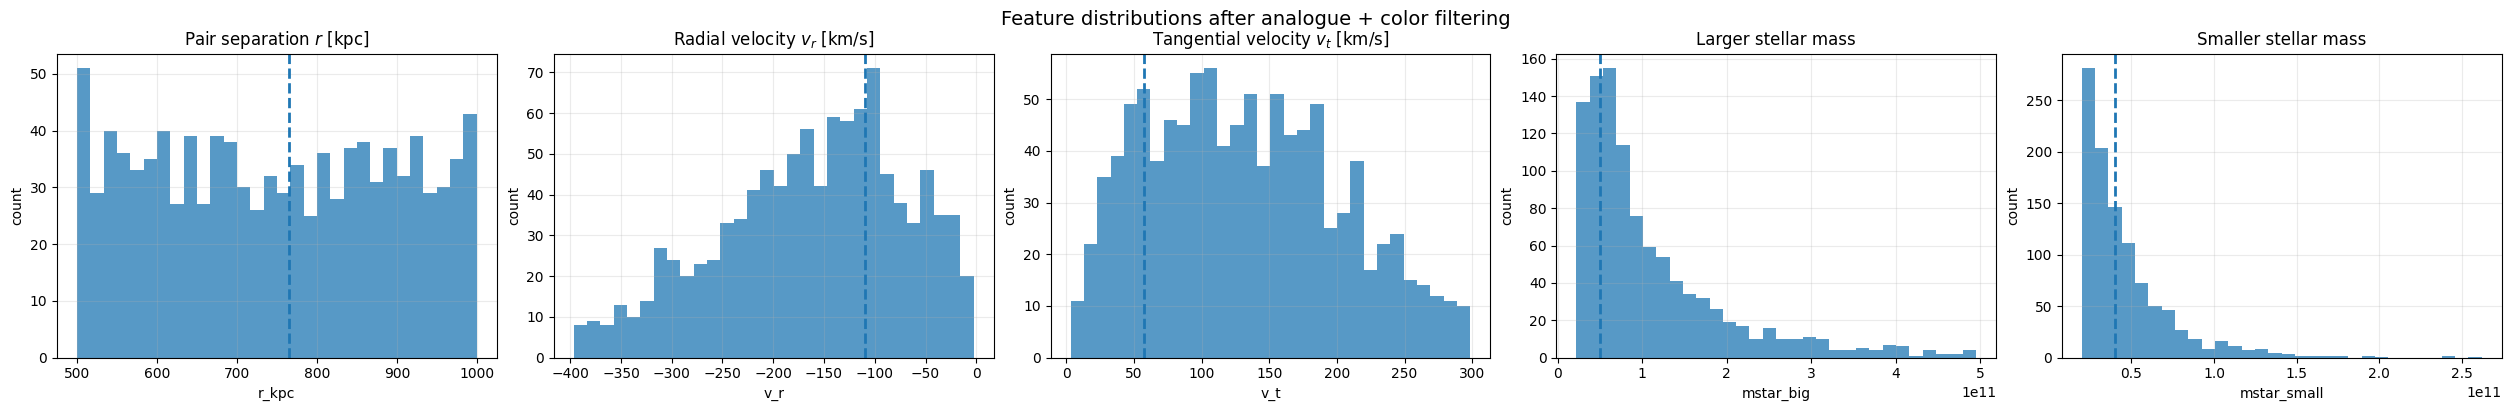

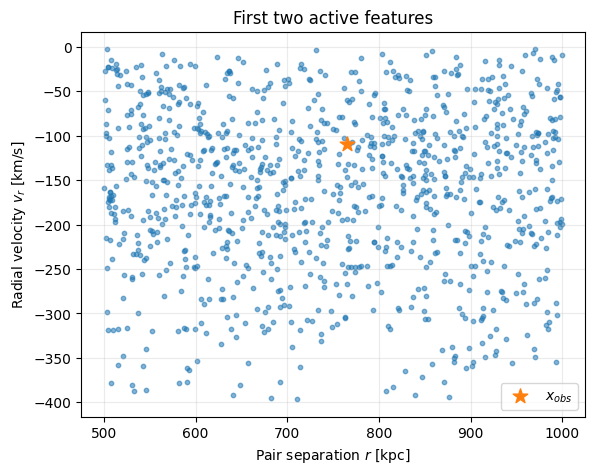

In [29]:
n_features = len(ACTIVE_FEATURES)
fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 3.8), constrained_layout=True)
if n_features == 1:
    axes = [axes]

for j, name in enumerate(ACTIVE_FEATURES):
    ax = axes[j]
    ax.hist(X[:, j], bins=30, alpha=0.75)
    ax.axvline(x_obs[j], linestyle="--", linewidth=2)
    ax.set_title(FEATURE_INFO[name].get("label", name))
    ax.set_xlabel(name)
    ax.set_ylabel("count")
    ax.grid(alpha=0.25)

fig.suptitle("Feature distributions after analogue + color filtering", y=1.04, fontsize=14)
plt.show()

if len(ACTIVE_FEATURES) >= 2:
    fig, ax = plt.subplots(figsize=(6.5, 5.0))
    ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.55)
    ax.scatter(x_obs[0], x_obs[1], s=120, marker="*", label="$x_{obs}$")
    ax.set_xlabel(FEATURE_INFO[ACTIVE_FEATURES[0]].get("label", ACTIVE_FEATURES[0]))
    ax.set_ylabel(FEATURE_INFO[ACTIVE_FEATURES[1]].get("label", ACTIVE_FEATURES[1]))
    ax.set_title("First two active features")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.show()


## 5) Run ABC kernel, GMM, and SBI on the same $(X, \theta, x_{\mathrm{obs}})$

- **ABC kernel**: smoothly weights retained rows by closeness to $x_{\mathrm{obs}}$
- **GMM**: fits a parametric joint model and conditions analytically
- **SBI / NPE**: learns a neural conditional posterior


In [30]:
# ABC kernel
abc_result = run_abc_catalog(
    X=X,
    theta=theta,
    x_obs=x_obs,
    sigma=sigma,
    accept_frac=ABC_HELPER_ACCEPT_FRAC,
    kernel_bandwidth=ABC_KERNEL_BANDWIDTH,
)

print("ABC kernel summary:")
print(abc_result["summary_kernel"])
print("ABC kernel ESS:", abc_result["ess"])

# GMM
gmm_fit = fit_joint_gmm(
    X=X,
    theta=theta,
    n_components=GMM_COMPONENTS,
    random_state=GMM_RANDOM_STATE,
)
gmm_result = condition_gmm(
    gmm_fit,
    x_obs=x_obs,
    n_samples=20_000,
    random_state=GMM_RANDOM_STATE,
)

print()
print("GMM summary:")
print(gmm_result["summary"])
print("GMM selected components:", gmm_fit["n_components"], "| selected_by:", gmm_fit["selected_by"])

# SBI
fit = fit_catalog_npe(
    X=X,
    theta=theta,
    x_obs=x_obs,
    feature_names=feature_names,
    target_name=target_name,
    **SBI_CONFIG,
)

sbi_result = infer_with_npe(
    fit,
    x_obs=x_obs,
    num_samples=20_000,
    random_state=SBI_CONFIG["random_state"],
    ppc_draws=500,
    ppc_neighbors=25,
)

print()
print("SBI summary:")
print(sbi_result["summary"])


ABC kernel summary:
{'mean': 12.68689709753038, 'median': 12.760383473524255, 'q16': 12.630906402504944, 'q84': 12.760660168658955, 'ess': 2.7352933324741815}
ABC kernel ESS: 2.7352933324741815

GMM summary:
{'mean': 12.583265763402931, 'median': 12.583598842426793, 'q16': 12.449904073195274, 'q84': 12.712200893735455}
GMM selected components: 6 | selected_by: bic
 Training neural network. Epochs trained: 1

/home/tp/Documents/uni/dsp/.venv/lib/python3.12/site-packages/sbi/neural_nets/net_builders/flow.py:149: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  x_numel = get_numel(


 Neural network successfully converged after 111 epochs.
SBI summary:
{'mean': 12.545551791667938, 'median': 12.5464186668396, 'q16': 12.434115295410157, 'q84': 12.657285003662109}


## 6) Build a side-by-side comparison table


In [31]:
def weighted_percentile_of_obs(values, weights, obs):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if values.ndim != 1 or weights.ndim != 1 or values.size != weights.size:
        raise ValueError("values and weights must be matching 1D arrays")
    total = weights.sum()
    if total <= 0:
        return np.nan
    wn = weights / total
    return float(wn[values <= obs].sum())


summary_rows = [
    {"method": "all retained pairs after S + color filter", **prior_summary},
    {"method": "ABC kernel", **abc_result["summary_kernel"], "ess": abc_result["ess"]},
    {"method": "GMM", **gmm_result["summary"]},
    {"method": "SBI", **sbi_result["summary"]},
]

summary_df = pd.DataFrame(summary_rows)

display(summary_df)


,method,mean,median,q16,q84,ess
0,all retained pairs after S + color filter,12.896249,12.829658,12.534827,13.307546,NaN
1,ABC kernel,12.686897,12.760383,12.630906,12.760660,2.735293
2,GMM,12.583266,12.583599,12.449904,12.712201,NaN
3,SBI,12.545552,12.546419,12.434115,12.657285,NaN


## 7) Posterior plots


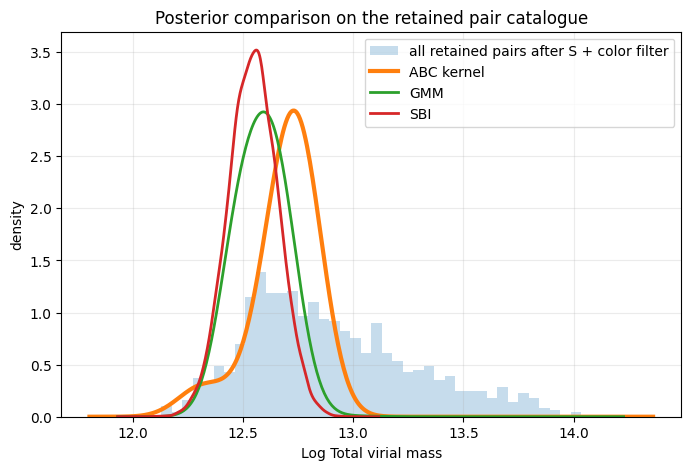

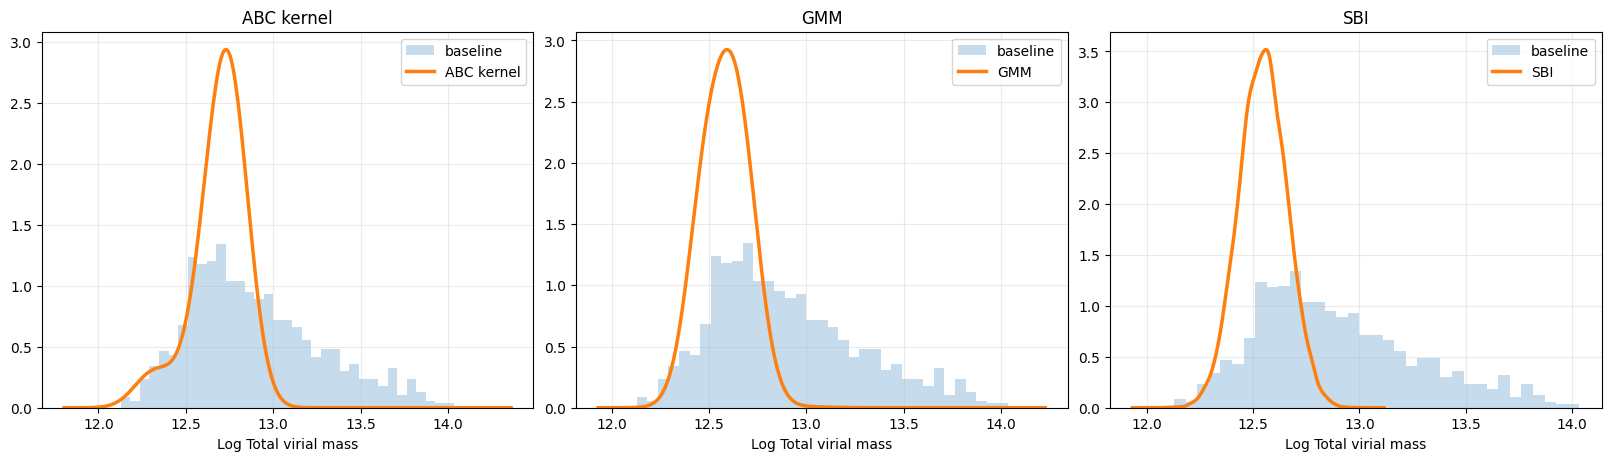

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(theta, bins=40, density=True, alpha=0.25, label="all retained pairs after S + color filter")

grid_abc_kernel, dens_abc_kernel = weighted_gaussian_kde_1d(theta, weights=abc_result["weights"])
ax.plot(grid_abc_kernel, dens_abc_kernel, linewidth=3, label="ABC kernel")

ax.plot(gmm_result["theta_grid"], gmm_result["theta_density"], linewidth=2, label="GMM")

grid_sbi, dens_sbi = weighted_gaussian_kde_1d(sbi_result["samples"])
ax.plot(grid_sbi, dens_sbi, linewidth=2, label="SBI")

ax.set_xlabel(target_name)
ax.set_ylabel("density")
ax.set_title("Posterior comparison on the retained pair catalogue")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

# Method-wise posterior panels
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

axes[0].hist(theta, bins=35, density=True, alpha=0.25, label="baseline")
axes[0].plot(grid_abc_kernel, dens_abc_kernel, linewidth=2.5, label="ABC kernel")
axes[0].set_title("ABC kernel")
axes[0].set_xlabel(target_name)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].hist(theta, bins=35, density=True, alpha=0.25, label="baseline")
axes[1].plot(gmm_result["theta_grid"], gmm_result["theta_density"], linewidth=2.5, label="GMM")
axes[1].set_title("GMM")
axes[1].set_xlabel(target_name)
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].hist(theta, bins=35, density=True, alpha=0.25, label="baseline")
axes[2].plot(grid_sbi, dens_sbi, linewidth=2.5, label="SBI")
axes[2].set_title("SBI")
axes[2].set_xlabel(target_name)
axes[2].grid(alpha=0.25)
axes[2].legend()

plt.show()


## 8) Feature-space comparison for ABC kernel and SBI

The ABC row reweights retained catalogue rows directly.
The SBI row shows the approximate posterior predictive from the SBI helper.


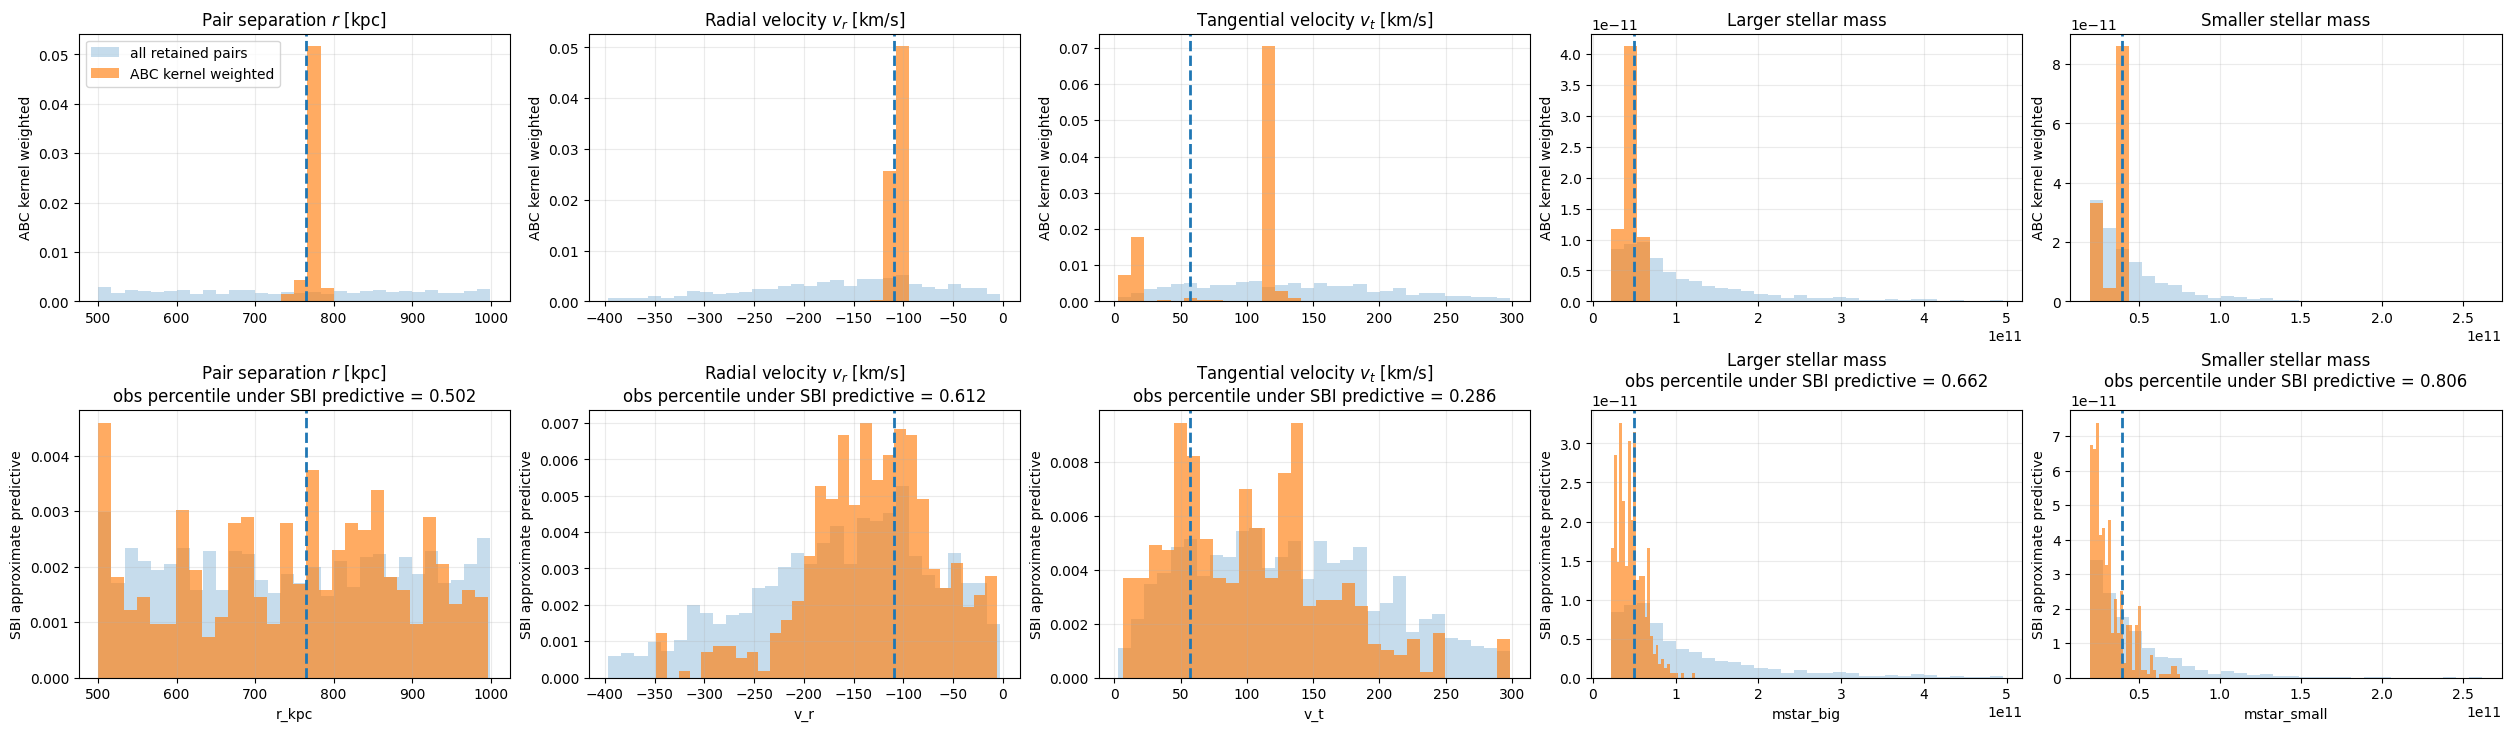

In [33]:
def weighted_hist(ax, values, weights=None, bins=30, alpha=0.5, label=None):
    ax.hist(values, bins=bins, weights=weights, density=True, alpha=alpha, label=label)


x_pred_sbi = sbi_result["x_predictive_samples"]

fig, axes = plt.subplots(
    2,
    len(ACTIVE_FEATURES),
    figsize=(5 * len(ACTIVE_FEATURES), 7.2),
    constrained_layout=True,
)
if len(ACTIVE_FEATURES) == 1:
    axes = np.array(axes).reshape(2, 1)

row_titles = ["ABC kernel weighted", "SBI approximate predictive"]

for j, name in enumerate(ACTIVE_FEATURES):
    base_values = X[:, j]

    ax = axes[0, j]
    weighted_hist(ax, base_values, bins=30, alpha=0.25, label="all retained pairs")
    weighted_hist(ax, base_values, weights=abc_result["weights"], bins=30, alpha=0.65, label="ABC kernel weighted")
    ax.axvline(x_obs[j], linestyle="--", linewidth=2)
    ax.set_title(FEATURE_INFO[name].get("label", name))
    ax.set_ylabel(row_titles[0])
    ax.grid(alpha=0.25)

    ax = axes[1, j]
    weighted_hist(ax, base_values, bins=30, alpha=0.25, label="all retained pairs")
    weighted_hist(ax, x_pred_sbi[:, j], bins=30, alpha=0.65, label="SBI predictive")
    ax.axvline(x_obs[j], linestyle="--", linewidth=2)
    pct = sbi_result["x_obs_predictive_percentile"][name]
    ax.set_ylabel(row_titles[1])
    ax.set_xlabel(name)
    ax.set_title(f"{FEATURE_INFO[name].get('label', name)}\nobs percentile under SBI predictive = {pct:.3f}")
    ax.grid(alpha=0.25)

axes[0, 0].legend()
plt.show()


## 9) Support check and interpretation helpers


In [34]:
support = sbi_result["support_check"]

support_df = pd.DataFrame({
    "feature": feature_names,
    "obs": x_obs,
    "feature_min": support["feature_min"],
    "feature_max": support["feature_max"],
    "outside_range": support["outside_range"],
    "nearest_feature_value": support["nearest_x"],
})

display(support_df)

print("n_outside =", support["n_outside"])
print("nearest_distance =", support["nearest_distance"])
print("nearest_index =", support["nearest_index"])


,feature,obs,feature_min,feature_max,outside_range,nearest_feature_value
0,r_kpc,7.650000e+02,5.003712e+02,9.996834e+02,False,7.660847e+02
1,v_r,-1.093000e+02,-3.965693e+02,-2.685917e+00,False,-1.318151e+02
2,v_t,5.700000e+01,6.452652e+00,2.984186e+02,False,6.193517e+01
3,mstar_big,5.000000e+10,2.216418e+10,4.894235e+11,False,3.965848e+10
4,mstar_small,4.000000e+10,2.002575e+10,2.403294e+11,False,3.273155e+10


n_outside = 0
nearest_distance = 0.3741850632100682
nearest_index = 749


## 10) SBI calibration and fit-quality plots


,train_size,calibration_size,mean_calibration_log_prob
0,820,205,0.573582


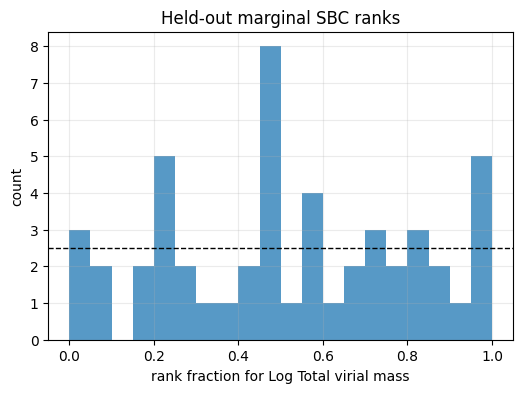

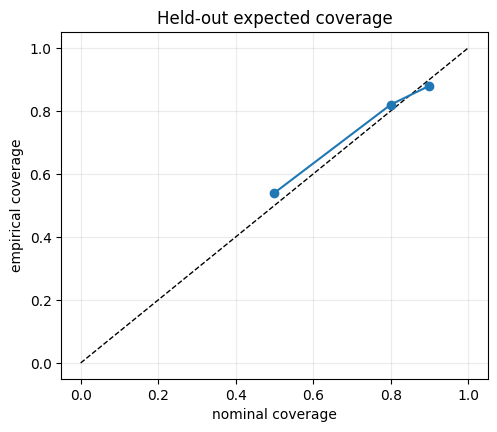

,n_components,bic
0,1,15468.984737
1,2,13512.684522
2,3,13503.263878
3,4,13440.828151
4,5,13369.077197
5,6,13296.263534
6,7,13415.197493
7,8,13547.377632


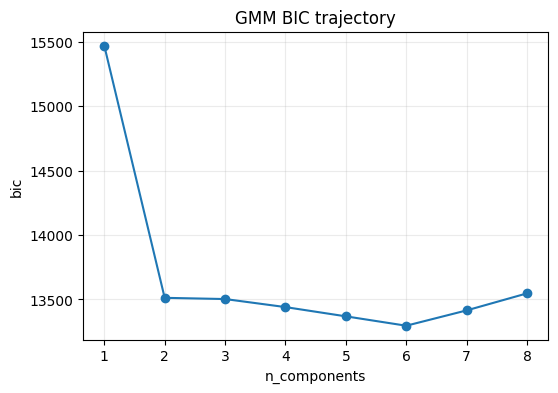

,method,loss_available,notes
0,ABC kernel,N/A,No optimizer/training loop.
1,GMM,Criterion table,BIC/AIC over component counts when auto-select...
2,SBI,Not exposed in helper output,Using calibration diagnostics instead.


In [35]:
diag = fit["diagnostics"]

display(pd.DataFrame([{
    "train_size": diag["train_size"],
    "calibration_size": diag["calibration_size"],
    "mean_calibration_log_prob": diag["mean_calibration_log_prob"],
}]))

if diag["sbc_ranks"].size > 0:
    plot_sbc_rank_hist(
        diag["sbc_ranks"],
        num_posterior_samples=diag["sbc_summary"].get("num_posterior_samples", 200),
        parameter_label=target_name,
        title="Held-out marginal SBC ranks",
    )
    plt.show()

coverage_data = diag.get("expected_coverage_1d", {})
if len(np.asarray(coverage_data.get("levels", []))) > 0:
    plot_expected_coverage(
        coverage_data,
        title="Held-out expected coverage",
    )
    plt.show()

# GMM fit-quality diagnostics (criterion trajectory if available)
if gmm_fit.get("selection_scores"):
    gmm_scores_df = pd.DataFrame(gmm_fit["selection_scores"])
    display(gmm_scores_df)

    # selection_scores uses the actual criterion name as column key, e.g. "bic" or "aic".
    candidate_cols = [c for c in gmm_scores_df.columns if c != "n_components"]
    if candidate_cols:
        crit_col = candidate_cols[0]
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(gmm_scores_df["n_components"], gmm_scores_df[crit_col], marker="o")
        ax.set_xlabel("n_components")
        ax.set_ylabel(crit_col)
        ax.set_title(f"GMM {crit_col.upper()} trajectory")
        ax.grid(alpha=0.25)
        plt.show()
    else:
        print("GMM selection score column not found in selection_scores.")
else:
    print("GMM criterion trajectory not available (manual n_components path).")

# Training-loss diagnostics availability note
loss_df = pd.DataFrame([
    {"method": "ABC kernel", "loss_available": "N/A", "notes": "No optimizer/training loop."},
    {"method": "GMM", "loss_available": "Criterion table", "notes": "BIC/AIC over component counts when auto-selection is used."},
    {"method": "SBI", "loss_available": "Not exposed in helper output", "notes": "Using calibration diagnostics instead."},
])
display(loss_df)



## 11) Residual diagnostics on held-out pseudo-observations


/home/tp/Documents/uni/dsp/.venv/lib/python3.12/site-packages/sbi/neural_nets/net_builders/flow.py:149: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  x_numel = get_numel(


 Neural network successfully converged after 99 epochs.

,method,mae,rmse,r2
0,ABC kernel,0.138926,0.174931,0.738521
1,GMM,0.098359,0.124875,0.866754
2,SBI,0.092639,0.118811,0.879382


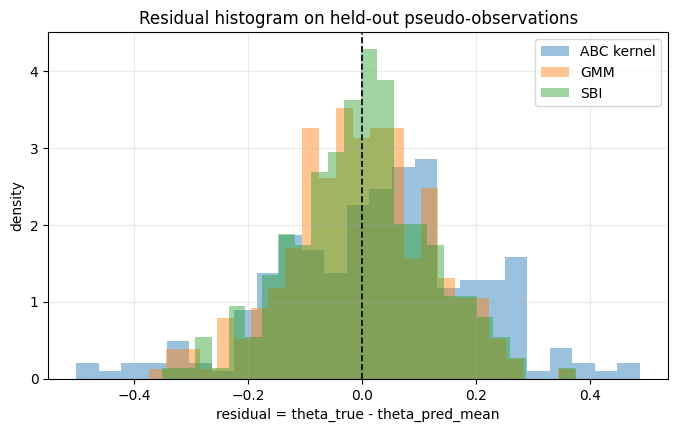

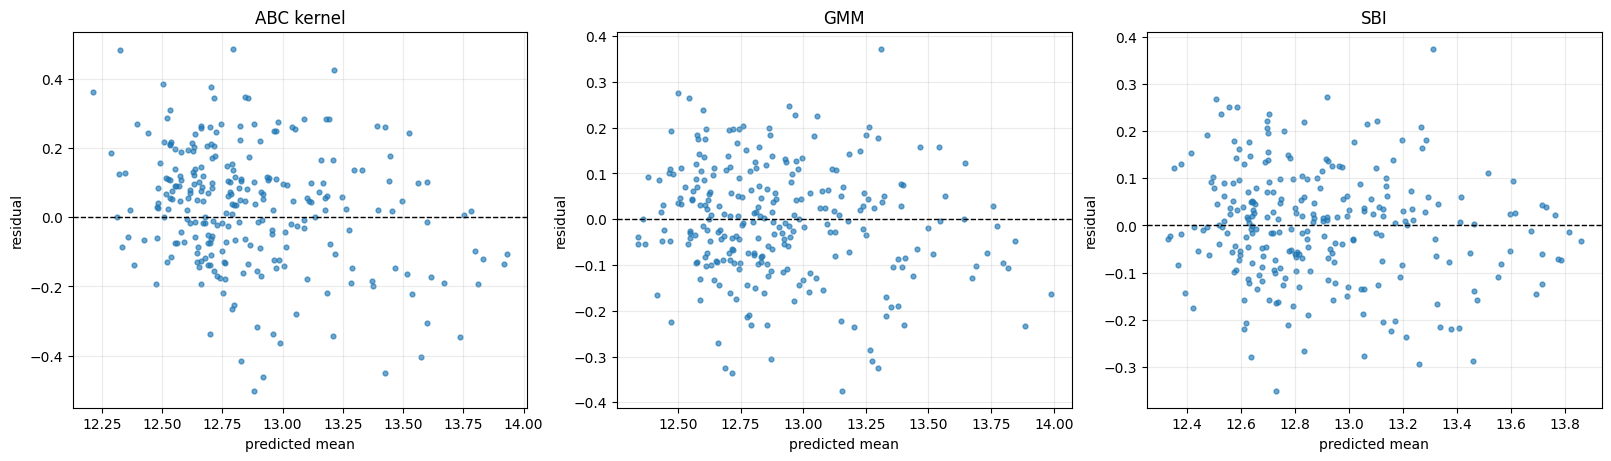

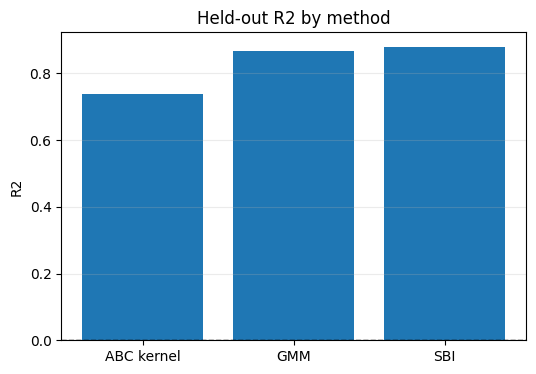

In [36]:
# Build a fixed train/test split on retained analogue rows.
idx = np.arange(X.shape[0])
train_idx, test_idx = train_test_split(idx, test_size=DIAG_TEST_FRACTION, random_state=DIAG_RANDOM_STATE)

X_train_diag = X[train_idx]
theta_train_diag = theta[train_idx]
X_test_diag = X[test_idx]
theta_test_diag = theta[test_idx]

# Refit models on train split for residual diagnostics.
abc_diag_fit = run_abc_catalog(
    X=X_train_diag,
    theta=theta_train_diag,
    x_obs=x_obs,
    sigma=sigma,
    accept_frac=ABC_HELPER_ACCEPT_FRAC,
    kernel_bandwidth=ABC_KERNEL_BANDWIDTH,
)

gmm_diag_fit = fit_joint_gmm(
    X=X_train_diag,
    theta=theta_train_diag,
    n_components=GMM_COMPONENTS,
    random_state=GMM_RANDOM_STATE,
)

sbi_diag_fit = fit_catalog_npe(
    X=X_train_diag,
    theta=theta_train_diag,
    x_obs=x_obs,
    feature_names=feature_names,
    target_name=target_name,
    **SBI_CONFIG,
)


def abc_pred_mean_for_x(xi):
    out = run_abc_catalog(
        X=X_train_diag,
        theta=theta_train_diag,
        x_obs=xi,
        sigma=sigma,
        accept_frac=ABC_HELPER_ACCEPT_FRAC,
        kernel_bandwidth=ABC_KERNEL_BANDWIDTH,
    )
    return float(out["summary_kernel"]["mean"])


def gmm_pred_mean_for_x(xi):
    out = condition_gmm(gmm_diag_fit, x_obs=xi, n_samples=3000, random_state=GMM_RANDOM_STATE)
    return float(out["summary"]["mean"])


def sbi_pred_mean_for_x(xi):
    out = infer_with_npe(sbi_diag_fit, x_obs=xi, num_samples=3000, random_state=SBI_CONFIG["random_state"], ppc_draws=100, ppc_neighbors=15)
    return float(out["summary"]["mean"])


abc_pred = np.array([abc_pred_mean_for_x(xi) for xi in X_test_diag])
gmm_pred = np.array([gmm_pred_mean_for_x(xi) for xi in X_test_diag])
sbi_pred = np.array([sbi_pred_mean_for_x(xi) for xi in X_test_diag])

residuals = {
    "ABC kernel": theta_test_diag - abc_pred,
    "GMM": theta_test_diag - gmm_pred,
    "SBI": theta_test_diag - sbi_pred,
}

metrics_rows = []
for method, pred in [("ABC kernel", abc_pred), ("GMM", gmm_pred), ("SBI", sbi_pred)]:
    metrics_rows.append({
        "method": method,
        "mae": mean_absolute_error(theta_test_diag, pred),
        "rmse": mean_squared_error(theta_test_diag, pred) ** 0.5,
        "r2": r2_score(theta_test_diag, pred),
    })

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)

# Residual histogram
fig, ax = plt.subplots(figsize=(8, 4.5))
for method, res in residuals.items():
    ax.hist(res, bins=25, alpha=0.45, density=True, label=method)
ax.axvline(0.0, color='k', linestyle='--', linewidth=1.2)
ax.set_xlabel('residual = theta_true - theta_pred_mean')
ax.set_ylabel('density')
ax.set_title('Residual histogram on held-out pseudo-observations')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

# Residual vs predicted
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
for ax, (method, pred) in zip(axes, [("ABC kernel", abc_pred), ("GMM", gmm_pred), ("SBI", sbi_pred)]):
    res = theta_test_diag - pred
    ax.scatter(pred, res, s=12, alpha=0.65)
    ax.axhline(0.0, color='k', linestyle='--', linewidth=1.0)
    ax.set_title(method)
    ax.set_xlabel('predicted mean')
    ax.set_ylabel('residual')
    ax.grid(alpha=0.25)
plt.show()

# R2 comparison
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(metrics_df['method'], metrics_df['r2'])
ax.axhline(0.0, color='k', linestyle='--', linewidth=1.0)
ax.set_ylabel('R2')
ax.set_title('Held-out R2 by method')
ax.grid(axis='y', alpha=0.25)
plt.show()
